# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [1]:
import os
import sys
from pathlib import Path
import time
import json
import numpy as np
#import diffusers
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
from pprint import pprint
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals

# Debugging Training Classes

In [3]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True

## Diffusion Training

In [141]:
def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "xbatch"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [1.0]
    tconfigs, mconfigs = [], []

    learning_rates = [5e-5, 5e-4]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = None
        tconfig.lr_warmup_steps = 500
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 2

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddom_diffusion'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



In [66]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "trial1"

num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [67]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

NameError: name 'setup_run' is not defined

wandb: 
wandb: 🚀 View run testing at: https://wandb.ai/samart-agr-columbia-university/diffusionsim/runs/o3m6hgxc
wandb: Find logs at: wandb/run-20250806_020044-o3m6hgxc/logs


In [ ]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

In [ ]:
trainer.train(num_epochs=1)

In [ ]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


In [ ]:
dataloaders, indices = tru.load_dataloaders(dconfig)

In [ ]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [ ]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [ ]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

## Train Clim

In [142]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices=False, 
                                batch_size=batch_size, use_tendencies=False,
                             )
    dconfig.train_test_split = [0.002, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 5e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.01, 0.1, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [20.0, 40.0, 20.0, 20.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': 0, 'distribution': 1, 'diffusion': 1}
        tconfig.loss_weight_params.update( dict(strategy="gradnorm", weights=loss_weights, schedule=loss_schedule))
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
#exp_id = "DiffLossTraining"
#un_id = "testing_just_mse"

In [ ]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = ""
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, "MultiTask", "testing", data_vars='v1', batch_size=64
)

In [ ]:
#dconfig.train_test_split = [0.001, 0.001]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.002, 0.001],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=True)


In [ ]:
trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)
self = trainer

NameError: name 'ClimsimTrainer' is not defined

In [ ]:
len(trainer.dataloaders['train']), #trainer.indices[0]


In [ ]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [ ]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [ ]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [ ]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [ ]:
x, y = next(iter(trainer.dataloaders['train']))

In [ ]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [ ]:
params[0] == after_params[0]

In [ ]:
after_params[0]

In [ ]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [ ]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## Implementing GradNorm

In [4]:
from collections import defaultdict
from sklearn.mixture import GaussianMixture
import math

In [5]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices=False, 
                                batch_size=batch_size, use_tendencies=False,
                             )
    dconfig.train_test_split = [0.002, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 5e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.01, 0.1, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [20.0, 40.0, 20.0, 20.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': 0, 'distribution': 1, 'diffusion': 1}
        tconfig.loss_weight_params.update( dict(strategy="gradnorm", weights=loss_weights, schedule=loss_schedule))
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [6]:
class ModelLens:
    def __init__(self, model: torch.nn.Module):
        self.model = model
        self.params = dict(model.named_parameters())
        self.param_names = [p for p in self.params]
    
    def get_param(self, getter):
        if isinstance(getter, str):
            return self.params[getter]
        elif isinstance(getter, int):
            return self.params[self.param_names[getter]]
        raise ValueError(f"Invalid getter: {getter}")

    def __getattr__(self, name):
        return getattr(self.model, name)
    
    def __call__(self, *args):
        return self.model(*args)

    def __repr__(self):
        return repr(self.model)
    def __str__(self):
        return str(self.model)


In [7]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, "MultiTask", "testing", data_vars='v1', batch_size=64
)
pprint(dconfig)

dataloaders, indices = tru.load_dataloaders(dconfig, log=True)
dl, edl = dataloaders
train_indices, test_indices = indices

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.002, 0.001],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [8]:
from abc import ABC, abstractmethod
import dataclasses
import wandb
import math
from diffusionsim.trainers import distribution_loss, diffusion_loss

class AbstractTrainer(ABC):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, rank):
        self.device = f'cuda:{rank}' if torch.cuda.is_available() else 'cpu'
        self.rank = rank
        self.phases = tconfigs[0].phases
        assert isinstance(mconfigs, list) and isinstance(tconfigs, list) and len(mconfigs) == len(tconfigs), "mconfigs and tconfigs must be lists of same length"
        self.dconfig, self.dutils = dataloaders[0].dataset.data_config, dataloaders[0].dataset.dutils
        self.indices = indices
        self.dataloaders = {self.phases[i] : dataloaders[i] for i in range(len(dataloaders))}

        self.loss_fn = torch.nn.MSELoss()
        self.number_of_models = len(mconfigs)
        self.base_run_id = base_run_id
        self.run_ids = [tconfig.run_id for tconfig in tconfigs]
        self.mconfigs, self.training_configs, self.models, self.optimizers, self.lr_schedulers = {}, {}, {}, {}, {}
        self.distributed = bool(tconfigs[0].distributed_training)
        for i, run_id in enumerate(self.run_ids):
            self.mconfigs[run_id], self.training_configs[run_id] = mconfigs[i], tconfigs[i]
            self.models[run_id] = tru.ModelLens(tru.load_model(mconfigs[i], device=self.device, distributed=self.distributed))
            self.optimizers[run_id] = tru.create_optimizer(self.models[run_id], self.training_configs[run_id])
            self.lr_schedulers[run_id] = tru.load_lr_scheduler(self.training_configs[run_id], self.optimizers[run_id], dataloaders[0])

        brid = self.base_run_id[:-1] if self.base_run_id[-1].isdigit() else self.base_run_id
        self.dirs = dict(
            log_dir = base_dir,
            ckpt_dir = os.path.join(base_dir, "checkpoints", brid),
            output_dir = os.path.join(base_dir, "outputs", brid),
        )
        
        self.log_file_path = os.path.join(self.dirs['log_dir'], f"{self.base_run_id}.json")
        self.bli = tconfigs[0].batch_logging_interval
        self.ckpt_interval = tconfigs[0].batch_checkpoint_interval
        self.logs_per_epoch = {phase : math.ceil(len(self.dataloaders[phase]) / self.bli) + 1 for phase in self.phases}
        self.restarted = False
        self.losses, self.gradients, self.best_losses, self.nan_incidents = {}, {}, {}, {}
        self.batches_per_epoch = dict(zip(self.phases, [len(self.dataloaders[phase]) for phase in self.phases]))
    
    def setup_training(self, num_epochs, log=True, save_indices=False):
        self.current_epoch = 0
        self.log = log
        for phase in self.phases:
            self.dataloaders[phase].dataset.log = log
        print(f"Getting ready to train {self.number_of_models} model(s) for {num_epochs} epochs on device {self.device}; configs at {self.log_file_path}", flush=True)
        self.losses, self.gradients, self.best_losses, self.nan_incidents = {}, {}, {}, {}
        self.batches_per_epoch = dict(zip(self.phases, [len(self.dataloaders[phase]) for phase in self.phases]))
        master_dict = {'data_config': dataclasses.asdict(self.dconfig)}
        if (self.dconfig.shuffle_indices and save_indices):
            # only need to save indices if were shuffled
            master_dict['indices'] = [i.tolist() for i in self.indices]
        for run_id in self.run_ids:
            tconfig = self.training_configs[run_id]
            tconfig.num_epochs = num_epochs
            if(tconfig.log_gradients):
                self.log_gradients = True
            master_dict[run_id] = dict(
                    training_config=dataclasses.asdict(tconfig),
                    model_config=dataclasses.asdict(self.mconfigs[run_id]),
            )
        
        if log:
            for dirname in self.dirs.values():
                Path(dirname).mkdir(parents=True, exist_ok=True)
            self.run = wandb.init(
                entity="samart-agr-columbia-university", 
                project="diffusionsim",
                name=self.base_run_id,
                config=master_dict,
            )
            
            print(f"Saving configs to {self.log_file_path}", flush=True)
            with open(self.log_file_path, "w") as f:
                json.dump(master_dict, f)
        

    def _save_checkpoint(self, run_id, cid='', **kwargs):
        model = self.models[run_id]
        ckp = model.module.state_dict() if self.distributed else model.state_dict()
        ckp = {k: v.detach().cpu() for k, v in ckp.items()}
        path = os.path.join(self.dirs['ckpt_dir'], f"{cid}{run_id}-ckpt.pt")
        torch.save(ckp, path)
        print(f"Model saved at {path}")
      
    def restart_from_ckpt(self, num_epochs, log, cid='', phase='train'):
        self.setup_training(num_epochs, log=log)
        self.restarted = True
        with open(self.log_file_path, 'r') as f:
            master_dict = json.load(f)
        for run_id in self.run_ids:
            ckpt_path = os.path.join(self.dirs['ckpt_dir'], f"{cid}{run_id}-ckpt.pt")
            if(os.path.exists(ckpt_path)):
                print(f"Loading checkpoint from {ckpt_path}")
                self.models[run_id].load_state_dict(torch.load(ckpt_path, map_location=self.device))
                #self.optimizers[run_id].load_state_dict(torch.load(ckpt_path))
                #self.lr_schedulers[run_id].load_state_dict(torch.load(ckpt_path))
            if('losses' in master_dict[run_id]):
                self.losses.setdefault(run_id, {}).update(master_dict[run_id]['losses'])
            if('gradients' in master_dict[run_id]):
                self.gradients.setdefault(run_id, {}).update(master_dict[run_id]['gradients'])
        if(phase == 'train'):
            self.train(num_epochs, log=log)
        else:
            self.evaluate()
    
    @abstractmethod
    def _run_batch(self, batch, phase):
        pass

    @abstractmethod
    def _run_epoch(self, epoch, log, phase):
        pass

    @abstractmethod
    def _log_epoch_info(self, phase):
        pass

    def train(self, num_epochs, log=True, run_eval_epoch=False):
        if not self.restarted:
            self.setup_training(num_epochs, log)
        for epoch in range(num_epochs):
            self.current_epoch = epoch
            print(f"Epoch {epoch}/{num_epochs-1}", flush=True)
            print("_" * 10, flush=True)
            self._run_epoch(epoch, log, phase="train")
            self._log_epoch_info(phase="train")
            if run_eval_epoch:
                self._run_epoch(epoch, log, phase="eval")
                self._log_epoch_info(phase="eval")
        self.finish_training(num_epochs)
    
    def finish_training(self, num_epochs, **kwargs):
        print(f"Finished training {self.number_of_models} model(s) for {num_epochs} epochs.", flush=True)
        losses = {}
        with open(self.log_file_path, "r") as f:
            master_dict = json.load(f)
        for i, run_id in enumerate(self.run_ids):
            log_dict = master_dict[run_id]  
            # Add losses for this model
            log_dict['losses'] = self.losses[run_id]
            log_dict['nan_incidents'] = self.nan_incidents.get(run_id)
            # Add any additional kwargs
            for key, value in kwargs.items():
                if(isinstance(value, dict)):
                    for k, v in value.items():
                        if(k not in self.run_ids):
                            log_dict[k] = v
                        elif(k == run_id):
                            # this assumes that the arg was argname={run_id: value for run_id}
                            log_dict[key] = v
                else:
                    log_dict[key] = value
            if self.training_configs[run_id].log_gradients:
                log_dict['gradients'] = self.gradients.setdefault(run_id, {})
            master_dict[run_id] = log_dict
        
        with open(self.log_file_path, "w") as f:
            json.dump(master_dict, f)
                    
        return 0


In [ ]:


class ClimsimTrainer(AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, rank=0, **kwargs):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, rank)
        self.tracked_losses = ["mse"]
        self.track_loss_weights = False
        for run_id in self.run_ids:
            lw_params = self.training_configs[run_id].loss_weight_params #@['weights']
            if(lw_params['weights']['distribution'] > 0 and "distribution" not in self.tracked_losses):
                self.tracked_losses.append("distribution")
            if(lw_params['weights']['diffusion'] > 0 and "diffusion" not in self.tracked_losses):
                self.tracked_losses.append("diffusion")
            if(lw_params['strategy'] == "gradnorm"):
                self.track_loss_weights = True
                self.gradnorm_loss_fn = torch.nn.L1Loss(reduction='sum')

        if ("diffusion" in self.tracked_losses):
            self.unet = kwargs['unet'] if('unet' in kwargs) else tru.load_diffusion_model().to(self.device)
            scheds = [kwargs['scheduler'] for _ in range(len(self.run_ids))] if 'scheduler' in kwargs else [tru.load_scheduler(mconfig) for mconfig in self.mconfigs.values()]
            self.schedulers = dict(zip(self.run_ids, scheds))
        #if ("distribution" in self.tracked_losses):
        
    def _make_image(self, y, image_dim=2):
        if not torch.is_tensor(y):
            y = torch.tensor(y)
        ds = self.dataloaders['train'].dataset
        # desired output is (BS, C, H, W)
        return(tru.imagify(y, ds.dutils, 'y', image_dim))

    def setup_training(self, num_epochs, log=True):
        super().setup_training(num_epochs, log)
        self.loss_weights, self.lw_optimizers, self.lw_history, self.L0 = {}, {}, defaultdict(list), {}
        for run_id in self.run_ids:
            lws = [self.training_configs[run_id].loss_weight_params['weights'][k] for k in self.tracked_losses]
            if self.track_loss_weights:
                lws = torch.tensor(lws, device=self.device, dtype=torch.float64).mul_(self.training_configs[run_id].loss_weight_params['T'] / sum(lws))
                self.loss_weights[run_id] = torch.nn.Parameter(lws)
                self.lw_optimizers[run_id] = torch.optim.SGD([self.loss_weights[run_id]], lr=self.training_configs[run_id].loss_weight_params['lr'])
                self.L0[run_id] = {}
            else: 
                self.loss_weights[run_id] = torch.tensor(lws, device=self.device, requires_grad=False, dtype=torch.float64)
    
    def _return_loss_weights(self, run_id, batch_losses=None):
        params = self.training_configs[run_id].loss_weight_params
        match params['strategy']:
            case "fixed":
                return(self.loss_weights[run_id])
            case "epoch_fixed":
                lws = self.loss_weights[run_id].clone()
                for i, loss_type in enumerate(self.tracked_losses):
                    loss_sched = params['schedule'][loss_type]
                    if (isinstance(loss_sched, int) and self.current_epoch < loss_sched):
                        lws[i] = 0
                    elif isinstance(loss_sched, list) and not (loss_sched[0] <= self.current_epoch < loss_sched[1]):
                        lws[i] = 0
                return(lws)
            case "gradnorm":
                assert batch_losses is not None, "losses must be provided for gradnorm loss weight strategy"
                retval = self.loss_weights[run_id].detach().clone()
                #retval = torch.nn.functional.softmax(retval) * params['T']
                self.lw_history[run_id].append(retval)
                return(retval)

    def _update_gradnorm_weights_old(self, run_id, batch_losses):
        params = self.training_configs[run_id].loss_weight_params
        W = self.loss_weights[run_id]
        losses = torch.stack([batch_losses[l] for l in self.tracked_losses]).detach()
        l0 = self.L0[run_id]['l0'].detach().clone()
        if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
            i = self.tracked_losses.index("distribution")
            l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
        loss_ratio = losses / l0
        grads = []
        param = self.models[run_id].get_param(params['gradnorm_layer'])
        for i, loss_type in enumerate(self.tracked_losses):
            grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
            grads.append(torch.norm(grad))
        grads = torch.stack(grads)
        target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
        gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
        if 'a' in run_id:
            print("loss weights before update\n", self.loss_weights[run_id])
        self.lw_optimizers[run_id].zero_grad()
        gradnorm_loss.backward(retain_graph=True)
        self.lw_optimizers[run_id].step()
        with torch.no_grad():
            if (W < 0).any():
                W = torch.exp(W)
            self.loss_weights[run_id] = torch.nn.Parameter((params['T'] * W/W.sum()).detach())
            self.lw_optimizers[run_id] = torch.optim.SGD([self.loss_weights[run_id]], lr=params['lr'])
        if 'a' in run_id:
            print("loss weights after updat and norm\n", self.loss_weights[run_id])
            
    def apply_loss(self, y_hat, x, y, batch_losses, run_id, step):
        #model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
        self.models[run_id].zero_grad()
        VAR_IND = None
        for loss_type in self.tracked_losses:
            if(loss_type == "mse"):
                loss = self.loss_fn(y_hat, y)
            elif(loss_type == "distribution"):
                loss, VAR_IND = distribution_loss(self, y_hat, y, run_id, step)
                batch_losses[run_id]['VAR_IND'] = VAR_IND
            elif(loss_type == "diffusion"):
                loss = diffusion_loss(self, y_hat, run_id)
            else:
                raise ValueError(f"Invalid loss type: {loss_type}")
            #if(self._gradients_ops(run_id, loss_type, loss, step)):
            #    self.nan_incidents[run_id][-1]['inputs'] = (x, y)
            #    loss = torch.tensor(0)
            batch_losses[run_id][loss_type] = loss
        losses = torch.stack([batch_losses[run_id][l] for l in self.tracked_losses])
        if('l0' not in self.L0[run_id]):
            self.L0[run_id]['l0'] = torch.clamp(losses.detach().clone(), max=1000)
        if VAR_IND is not None and VAR_IND not in self.L0[run_id]:
            self.L0[run_id][VAR_IND] = batch_losses[run_id]['distribution']
        return(losses)
    
    def _update_gradnorm_weights(self, run_id, batch_losses):
        params = self.training_configs[run_id].loss_weight_params
        W = self.loss_weights[run_id]
        assert W.requires_grad, "loss_weights must require grad"
		# Detach per-task scalar losses for ratio computation
        losses_detached = torch.stack([batch_losses[l] for l in self.tracked_losses]).detach()
        l0 = self.L0[run_id]['l0'].detach().clone()
        if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
            i = self.tracked_losses.index("distribution")
            l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
        loss_ratio = losses_detached / l0
        param = self.models[run_id].get_param(params['gradnorm_layer'])

		# Compute gradient norms per task
        grads = []
        for i, loss_type in enumerate(self.tracked_losses):
            grad_i = torch.autograd.grad(
				W[i] * batch_losses[loss_type],
				param,
				retain_graph=True,    # Needed to get grads for each loss_type
				create_graph=True     # Needed to allow backprop through grad norms
            )[0]
            grads.append(torch.norm(grad_i))
        grads = torch.stack(grads)

		# Target gradients are treated as constants
        target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
        gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
        self.lw_optimizers[run_id].zero_grad()
        gradnorm_loss.backward()  # No retain_graph here — we're done with it
        self.lw_optimizers[run_id].step()

		# Normalize loss weights, detaching from graph completely
        with torch.no_grad():
            if (W < 0).any():
                W.copy_(torch.exp(W))
            W.copy_(params['T'] * W / W.sum())

		# Recreate optimizer with detached parameter to avoid linking to old graph
        self.loss_weights[run_id] = torch.nn.Parameter(W.detach())
        self.lw_optimizers[run_id] = torch.optim.SGD([self.loss_weights[run_id]], lr=params['lr'])

    def _run_batch(self, x, y, phase, step):
        #if self.log:
		#    t0 = tru.log_event("run-batch start", step=step)
        batch_losses = {}
        for run_id in self.run_ids:
            print("\n", run_id)
            batch_losses[run_id] = {}
            y_hat = self.models[run_id](x) 
            losses = self.apply_loss(y_hat, x, y, batch_losses, run_id, step)
            self._update_gradnorm_weights(run_id, batch_losses[run_id])
            y_hat = self.models[run_id](x)
            losses = self.apply_loss(y_hat, x, y, batch_losses, run_id, step)
            loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
            total_loss = loss_weights @ losses
		#if(step % self.training_configs[run_id].loss_weight_params['update_interval'] == 0):

            if phase == 'train':
                self.optimizers[run_id].zero_grad()
                total_loss.backward(retain_graph=True)
                if(self.training_configs[run_id].clip_gradients):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(self.models[run_id].parameters(), max_norm=1.0)
                self.optimizers[run_id].step()
                if(self.lr_schedulers[run_id] is not None):
                    self.lr_schedulers[run_id].step()
            batch_losses[run_id]['total'] = total_loss.item()
        #if(self.log):
        #    tru.log_event("run-batch end", duration=time.time() - t0, step=step, loss=[batch_losses[run_id]['total'] for run_id in self.run_ids])
        return(batch_losses)
    
    def _gradients_ops(self, run_id, loss_type, loss, step):
        #assert loss_type in self.tracked_losses, f"loss_type {loss_type} must be one of {self.tracked_losses}"
        model, optimizer = self.models[run_id], self.optimizers[run_id]
        
        if not torch.isfinite(loss):
            return register_incident(self, "LOSS is not finite (NaN or Inf)", step, run_id, loss_type, loss=loss.detach())

        if (self.training_configs[run_id].log_gradients and step % self.bli == 0):
            optimizer.zero_grad(set_to_none=True)           # clean slate
            loss.backward(retain_graph=True)
            gdict = self.gradients.setdefault(run_id, {}).setdefault(loss_type, {})
            for n, p in model.named_parameters():
                if(p.grad is None):
                    continue
                if torch.isfinite(p.grad).all():
                    gdict.setdefault(n, []).append(
                        (p.grad.mean().item(), p.grad.std().item())
                    )
                else:
                    return register_incident(self, "GRAD has NaN/Inf", step, run_id, loss_type, loss=loss.detach(), 
                        tensor_name=n, tensor=p.grad, state_dict={k: v.clone().cpu() for k, v in model.state_dict().items()})
        optimizer.zero_grad(set_to_none=True)
        return 0

    def _run_epoch(self, epoch, log, phase='train'):
        for run_id in self.run_ids:
            self.models[run_id].train(phase=='train')
        if log:
            e0 = tru.log_event(f"epoch-{epoch} start")
        with torch.set_grad_enabled(phase=='train'):
            if(self.distributed):
                self.dataloaders[phase].sampler.set_epoch(epoch)
            num_steps = len(self.dataloaders[phase])
            for step, (X, Y) in enumerate(self.dataloaders[phase]):
                #if(step % (num_steps // 4) == 0):
                print("________________________________________________")
                print(f"Currently at epoch {epoch}, step {step}/{num_steps}\n________________________________________________", flush=True)                
                batch_losses = self._run_batch(X.to(self.device), Y.to(self.device), phase, step)
                if(batch_losses is None):
                    print(f"Batch {step} is bad; stopping", flush=True)
                    break
                self.log_step(batch_losses, step, phase, log)
                del batch_losses
        if log:
            tru.log_event(f"epoch-{epoch} end", duration=time.time() - e0)

    def log_step(self, batch_losses, step, phase, wandb=False):
        if(wandb):
            wandb_metrics = {"epoch" : self.current_epoch}
            for run_id in self.run_ids:
                if('distribution' in self.tracked_losses):
                    wandb_metrics[f"{phase}/{run_id}/distloss_var"] = batch_losses[run_id]['VAR_IND']
                for loss_type in self.tracked_losses:
                    wandb_metrics[f"{phase}/{run_id}/{loss_type}"] = batch_losses[run_id][loss_type]
            #global_step = self.current_epoch * len(self.dataloaders[phase]) + step
            self.run.log(wandb_metrics)
        
        if (step % self.bli == 0 or step + 1 == len(self.dataloaders[phase])):
            for run_id in self.run_ids:
                ldict = self.losses.setdefault(run_id, {}).setdefault(phase, {})
                for loss_type in self.tracked_losses:
                    ldict.setdefault(loss_type, []).append(batch_losses[run_id][loss_type].item())
                    if loss_type == 'distribution':
                        ldict.setdefault('distloss_var', []).append(batch_losses[run_id]['VAR_IND'])
        
        if ( (step + 1) % self.ckpt_interval == 0 and phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
        
    def _log_epoch_info(self, phase='train'):
        with open(self.log_file_path, "r") as f:
            master_dict = json.load(f)
        print("\n\n", flush=True)
        for run_id in self.run_ids:
            ldict = self.losses.setdefault(run_id, {}).setdefault(phase, {})
            for loss_type in self.tracked_losses:
                epoch_loss = ldict[loss_type][-self.logs_per_epoch[phase]:]
                avg_loss = sum(epoch_loss) / len(epoch_loss)
                print(f"avg {loss_type} loss for epoch {self.current_epoch}, {run_id=}: {avg_loss}", flush=True)
                if(phase == 'train' and loss_type == 'total' and avg_loss < self.best_losses.setdefault(run_id, float('inf'))):
                    print(f"new best! saving new checkpoint at epoch {epoch_num}", flush=True)
                    self.best_losses[run_id] = avg_loss
                    self._save_checkpoint(run_id, cid='best-')
            
            master_dict[run_id]['losses'] = self.losses[run_id]
            if(phase == 'train'):
                master_dict[run_id]['gradients'] = self.gradients[run_id]
        with open(self.log_file_path, "w") as f:
            json.dump(master_dict, f)

In [22]:
trainer = ClimsimTrainer([dl, edl], [indices], mconfigs, tconfigs, os.path.join(exp_dir, "MultiTask"), "testing", rank=0)
trainer.distloss_var_counts = {}
self = trainer
self.run_ids = self.run_ids[:1]

In [23]:
with torch.autograd.set_detect_anomaly(True):
	trainer.train(1, log=False)

Getting ready to train 2 model(s) for 1 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Epoch 0/0
__________
________________________________________________
Currently at epoch 0, step 0/6
________________________________________________

 testinga
________________________________________________
Currently at epoch 0, step 1/6
________________________________________________

 testinga
________________________________________________
Currently at epoch 0, step 2/6
________________________________________________

 testinga


/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Error detected in DivBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/srv/conda/envs/notebook/lib/python3.12/asyncio/base_events.py", line 640, in run_forever
    self._run_once()
  File "/srv/conda/envs/notebook/lib/pytho

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [26]:
torch.optim.SGD

torch.optim.sgd.SGD

In [176]:
print((self.loss_weights[run_id] > 0).any())
if (self.loss_weights[run_id] > 0).any():
    print(0)

tensor(True, device='cuda:0')
0


In [ ]:
torch.exp(W) / torch.exp(W).sum() 

tensor([0.0590, 0.0512, 0.8897], device='cuda:0', dtype=torch.float64,
       grad_fn=<DivBackward0>)

In [181]:
torch.softmax(W, dim=0)

tensor([0.0590, 0.0512, 0.8897], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftmaxBackward0>)

In [160]:
dl = iter(self.dataloaders['train'])
trainer.setup_training(2, log=False)

Getting ready to train 2 model(s) for 2 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json


In [163]:
x, y = next(dl)

image_dim is None, returning original tensor
image_dim is None, returning original tensor


In [164]:
batch_losses = self._run_batch(x.to(self.device), y.to(self.device), 'train', 0)


 testinga
losses: tensor([4.6282, 0.7851, 0.0713], device='cuda:0', dtype=torch.float64,
       grad_fn=<StackBackward0>)
loss_weights: tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after update
 Parameter containing:
tensor([0.2025, 0.1292, 2.7009], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after updat and norm
 Parameter containing:
tensor([0.2129, 0.1978, 2.5893], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

 testingb
losses: tensor([4.6319e+00, 7.9094e+01, 7.2605e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)
loss_weights: tensor([0.1641, 0.1462, 2.6897], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1641, 0.1462, 2.6897], device='cuda:0', dtype=torch.float64,
 

In [97]:
batch_losses = self._run_batch(x.to(self.device), y.to(self.device), 'train', 0)


 testinga
losses: tensor([ 4.6488, 14.4846,  0.0746], device='cuda:0', dtype=torch.float64,
       grad_fn=<StackBackward0>)
loss_weights: tensor([0.1851, 0.1607, 2.6542], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1851, 0.1607, 2.6542], device='cuda:0', dtype=torch.float64,
       requires_grad=True)


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [42]:
run_id = 'testinga'
self.loss_weights[run_id], self.loss_weights[run_id].grad_fn, self.loss_weights[run_id].grad

(Parameter containing:
 tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
        requires_grad=True),
 None,
 tensor([-4.6924e-01,  2.4750e+02, -2.6382e-02], device='cuda:0',
        dtype=torch.float64))

In [43]:
batch_losses

{'testinga': {'mse': tensor(4.6504, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 73,
  'distribution': tensor(68.9273, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0715, device='cuda:0', grad_fn=<MseLossBackward0>),
  'total': 0.966773894154823},
 'testingb': {'mse': tensor(4.6203, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 73,
  'distribution': tensor(82.4331, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0716, device='cuda:0', grad_fn=<MseLossBackward0>),
  'total': 1.14814804429708}}

In [31]:
self.log_step(batch_losses, 0, "train", False)

In [45]:
x, y = next(dl)

image_dim is None, returning original tensor
image_dim is None, returning original tensor


In [ ]:
self.L0['testinga']

{'l0': tensor([ 4.6504, 68.9273,  0.0715], device='cuda:0', dtype=torch.float64),
 73: tensor(68.9273, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>)}

In [51]:
print("\n", run_id)
batch_losses[run_id] = {}
y_hat = self.models[run_id](x.to(device)) 
losses = self.apply_loss(y_hat, x, y.to(device), batch_losses, run_id, step=1)
print("losses:", losses)
loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
print("loss_weights:", loss_weights)
total_loss = loss_weights @ losses


 testinga
losses: tensor([4.6625e+00, 1.2034e+02, 7.1509e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)
loss_weights: tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)


In [55]:
losses

tensor([4.6625e+00, 1.2034e+02, 7.1509e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)

In [58]:
self.loss_weights['testinga']

Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

In [59]:
self._update_gradnorm_weights(run_id, batch_losses[run_id])

loss weights before update Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after update Parameter containing:
tensor([0.2025, 0.1222, 2.7009], device='cuda:0', dtype=torch.float64,
       requires_grad=True)


In [63]:
self.optimizers[run_id].zero_grad()
total_loss.backward(retain_graph=False)

In [62]:
self.lw_history[run_id]

[tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], device='cuda:0',
        dtype=torch.float64),
 tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)]

In [78]:
trainer.dirs

{'log_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask',
 'ckpt_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask/checkpoints/testing',
 'output_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask/outputs/testing'}

In [ ]:
tconfig = self.training_configs[run_id]
pprint(tconfig)

TrainingConfig(exp_id='MultiTask',
               run_id='testingb',
               num_epochs=2,
               phases=['train', 'eval'],
               distributed_training=False,
               optimizer='adam',
               betas=(0.9, 0.999),
               lr_scheduler=None,
               learning_rate=0.00025,
               loss_weight_params={'T': 3.0,
                                   'alpha': 0.5,
                                   'gradnorm_layer': -2,
                                   'lr': 0.025,
                                   'schedule': {'diffusion': 1,
                                                'distribution': 1,
                                                'mse': 0},
                                   'strategy': 'gradnorm',
                                   'update_interval': 5,
                                   'weights': {'diffusion': 40.0,
                                               'distribution': 0.1,
                                       

In [ ]:
y_hat

NameError: name 'y_hat' is not defined

In [ ]:
self.setup_training(5, log=False)
run = evals.Run("DiffLossTesting",  "trial4")
for j, run_id in enumerate(self.run_ids):
    self.losses[run_id] = run.get("losses", j)
    ldict = self.losses[run_id]['train']
    choices = self.training_configs[run_id].distloss_var_inds
    ldict['distloss_var'] = list(np.random.choice(choices, size=len(ldict['distribution'])))
    self.L0[run_id]['l0'] = torch.tensor([ldict[l][0] for l in self.tracked_losses]).to(self.device)
    for i, var in enumerate(ldict['distloss_var']):
        if var not in self.L0[run_id]:
            self.L0[run_id][var] = torch.tensor(ldict['distribution'][i])

self.L0

Getting ready to train 2 model(s) for 5 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json


{'testinga': {'l0': tensor([4.5794e+00, 9.1391e+01, 7.4890e-02], device='cuda:0'),
  np.int64(68): tensor(91.3914),
  np.int64(82): tensor(0.5397),
  np.int64(73): tensor(8.4719)},
 'testingb': {'l0': tensor([4.6067, 1.3986, 0.0730], device='cuda:0'),
  np.int64(73): tensor(1.3986),
  np.int64(68): tensor(0.2611),
  np.int64(82): tensor(3.9456)}}

In [ ]:
run_ids = trainer.run_ids
run_id = run_ids[0]
model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
y_hat = model(x)
y_hat.shape

torch.Size([49152, 128])

In [ ]:
batch_losses = {run_id:{}}
losses = self.apply_loss(y_hat, x, y, batch_losses, run_id, step=0)
batch_losses = batch_losses[run_id]
losses, batch_losses

(tensor([4.2988e-02, 2.9295e+04, 7.1110e-02], device='cuda:0',
        dtype=torch.float64, grad_fn=<StackBackward0>),
 {'mse': tensor(0.0430, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 82,
  'distribution': tensor(29294.6312, device='cuda:0', dtype=torch.float64,
         grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0711, device='cuda:0', grad_fn=<MseLossBackward0>)})

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses = torch.stack([batch_losses[l].detach() for l in self.tracked_losses])
l0 = self.L0[run_id]['l0']
if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
    i = self.tracked_losses.index("distribution")
    l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
loss_ratio = losses / l0
grads = []
param = self.models[run_id].get_param(params['gradnorm_layer'])
for i, loss_type in enumerate(self.tracked_losses):
    grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
    grads.append(torch.norm(grad))
grads = torch.stack(grads)
target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
print("loss weights before update", self.loss_weights[run_id])
self.lw_optimizers[run_id].zero_grad()
gradnorm_loss.backward()
self.lw_optimizers[run_id].step()
print("loss weights after update", self.loss_weights[run_id])

loss weights before update Parameter containing:
tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)
loss weights after update Parameter containing:
tensor([ 1.4529e-01, -1.0721e-03,  2.8583e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)


In [ ]:
datasets

In [ ]:
self.dataloaders['train'].dataset = datasets[0]

ValueError: dataset attribute should not be set after DataLoader is initialized

In [ ]:
W

Parameter containing:
tensor([0.1771, 0.1530, 2.6699], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

In [ ]:
with torch.no_grad():
    W.mul_(1.1)# = torch.nn.functional.softmax(W) * params['T']
    print(W)

Parameter containing:
tensor([ 1.7580e-01, -1.2973e-03,  3.4585e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)


In [ ]:
self.loss_weights[run_id] is W

True

In [ ]:
#self._update_gradnorm_weights(run_id, batch_losses)
loss_weights = self._return_loss_weights(run_id, batch_losses)
loss_weights @ losses

tensor(4482.2669, device='cuda:0', dtype=torch.float64)

In [ ]:
softmax = lambda x : torch.nn.functional.softmax(torch.tensor(x), dim=0)
softplus = lambda x : torch.nn.functional.softplus(torch.tensor(x)) / torch.nn.functional.softplus(torch.tensor(x)).sum()
#
# softmax([0.01, 0.01, 5])
x = [1e-4, -4, 0.84]
print(softmax(x), softplus(x))


tensor([0.2999, 0.0055, 0.6946]) tensor([0.3629, 0.0095, 0.6276])


In [ ]:
W.grad_fn

In [ ]:
torch.nn.functional.softplus(W)

tensor([0.7684, 0.6926, 2.9141], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
torch.nn.functional.softmax(W)

/tmp/ipykernel_846051/2306342748.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.nn.functional.softmax(W)


tensor([0.0590, 0.0510, 0.8900], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftmaxBackward0>)

In [ ]:
with torch.no_grad():
    Ws = torch.nn.functional.softplus(W)
    Ws *= params['T'] / (Ws.sum() + 1e-7)
    print(Ws)

tensor([0.5269, 0.4749, 1.9982], device='cuda:0', dtype=torch.float64)


In [ ]:
with torch.no_grad():
    Ws = torch.nn.functional.softmax(W, dim=0) * params['T']
    print(Ws)

tensor([0.1771, 0.1530, 2.6699], device='cuda:0', dtype=torch.float64)


In [ ]:
grads, target_grads

(tensor([1.9404e-03, 5.5149e+02, 1.5395e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([  2.8435, 317.0862,  28.8727], device='cuda:0', dtype=torch.float64))

In [ ]:
self.L0[run_id]['l0'].device

device(type='cpu')

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses = torch.stack([batch_losses[run_id][l].detach() for l in self.tracked_losses])
l0 = self.L0[run_id]['l0']
print(l0)
if "VAR_IND" in batch_losses[run_id] and batch_losses[run_id]['VAR_IND'] in self.L0[run_id]:
    i = self.tracked_losses.index("distribution")
    print(i, batch_losses[run_id]['VAR_IND'])
    print(self.L0[run_id][batch_losses[run_id]['VAR_IND']])
    print(l0[i])




tensor([[4.5794e+00, 9.1391e+01, 7.4890e-02]])
1 82
tensor(-3.2564)


IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
self.L0[run_id]

{'l0': tensor([[4.5794e+00, 9.1391e+01, 7.4890e-02]]),
 np.int64(73): tensor(91.3914),
 np.int64(68): tensor(0.5397),
 np.int64(82): tensor(-3.2564)}

In [ ]:
batch_losses

{'testinga': {'mse': tensor(0.0436, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 82,
  'distribution': tensor(40507.3984, device='cuda:0', dtype=torch.float64,
         grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0707, device='cuda:0', grad_fn=<MseLossBackward0>)}}

In [ ]:
step = 0
batch_losses = {run_id : {}}
print(self.tracked_losses, "\n\n")
losses = torch.stack([self.apply_loss(y_hat, x, y, loss_type, batch_losses, run_id, step) for loss_type in self.tracked_losses])

batch_losses = batch_losses['testinga']
batch_losses

['mse', 'distribution', 'diffusion'] 


73


{'mse': tensor(0.0448, device='cuda:0', grad_fn=<MseLossBackward0>),
 'VAR_IND': 73,
 'distribution': tensor(4152.1830, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 'diffusion': tensor(0.0708, device='cuda:0', grad_fn=<MseLossBackward0>)}

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses, VAL_IND = torch.stack([batch_losses[l].detach() for l in self.tracked_losses]), batch_losses['VAR_IND']
print(VAL_IND)
l0 = self.L0[run_id].get(VAL_IND, None)
if l0 is None:
    l0 = list(self.L0[run_id].values())[0] if len(self.L0[run_id]) > 0 else torch.ones_like(losses)
loss_ratio = losses / l0.to(losses.device)
loss_ratio ** 0.5

68


tensor([ 0.2117, 63.9347,  0.2663], device='cuda:0', dtype=torch.float64)

In [ ]:
grads = []
param = self.models[run_id].get_param(params['gradnorm_layer'])
for i, loss_type in enumerate(self.tracked_losses):
    grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
    print(torch.norm(torch.autograd.grad(batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]).item())
    grads.append(torch.norm(grad))
grads = torch.stack(grads)
grads

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** 0.1
gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
gradnorm_loss, target_grads, grads

(tensor(503.7187, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>),
 tensor([ 61.7076, 223.3988,  64.9819], device='cuda:0', dtype=torch.float64),
 tensor([2.2250e-03, 6.0045e+02, 1.8035e-02], device='cuda:0',
        grad_fn=<StackBackward0>))

In [ ]:
print("loss weights before update", self.loss_weights[run_id])
self.lw_optimizers[run_id].zero_grad()
gradnorm_loss.backward()
self.lw_optimizers[run_id].step()
print("loss weights after update", self.loss_weights[run_id])
with torch.no_grad():
    W.mul_(params['T'] / W.sum())

loss weights before update Parameter containing:
tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], requires_grad=True)
loss weights after update Parameter containing:
tensor([ 0.1678, -0.0236,  2.8808], requires_grad=True)


In [ ]:
W, self.loss_weights[run_id]

(Parameter containing:
 tensor([ 0.3328, -0.0468,  5.7139], requires_grad=True),
 Parameter containing:
 tensor([ 0.3328, -0.0468,  5.7139], requires_grad=True))

In [ ]:
(loss_ratio / loss_ratio.mean()) ** 0.1

tensor([0.3206, 1.1161, 0.3388], device='cuda:0', dtype=torch.float64)

In [ ]:
self.L0[run_id][73] = torch.tensor([self.losses['testinga']['train'][l][0] for l in self.tracked_losses])

False

In [ ]:
print("mse : ", self.losses[run_id]['train']['mse'][:3])
print("distribution : ", self.losses[run_id]['train']['distribution'][:6])
print("diffusion : ", self.losses[run_id]['train']['diffusion'][:3])


print(self.losses[run_id]['train']['distloss_var'][:7])

mse :  [4.579434871673584, 1.5953820943832397, 0.5841066241264343]
distribution :  [91.39145117909806, 0.5397367975602321, 8.471865611125404, 0.2730342224641375, 0.008982313014709009, -3.256379498835006]
diffusion :  [0.07489027082920074, 0.052291955798864365, 0.047195278108119965]
[np.int64(82), np.int64(73), np.int64(68), np.int64(73), np.int64(68), np.int64(73), np.int64(68)]


In [ ]:
loss_ratios

tensor([9.9237e-01, 6.9291e-04, 9.5203e-01], device='cuda:0')

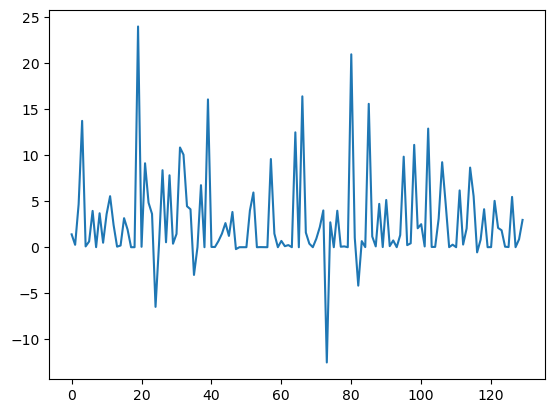

In [ ]:
plt.plot(self.losses[run_id]['train']['distribution'])

In [ ]:
run.logs['trial4-joint'].keys()

dict_keys(['training_config', 'model_config', 'train_epoch_losses', 'losses', 'gradients', 'distloss_var_counts'])

In [ ]:
self.losses[run_id]["train"].keys() # ["mse"][0]

dict_keys(['mse', 'total', 'diffusion', 'distribution'])

In [ ]:
plt.plot(self.losses[run_id]["train"]["mse"])

In [ ]:
losses.dtype

tensor([4.5432e+00, 1.3915e+02, 7.4138e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)

In [ ]:
trainer.loss_weights['testinga'].type(torch.float64) @ losses

tensor(7.4175, device='cuda:0', dtype=torch.float64, grad_fn=<DotBackward0>)

In [ ]:
grad_norms, ratios = self._return_loss_weights(run_id, losses)

In [ ]:
d = {}

d.get('a', 0)

0

In [ ]:
[self.losses[run_id]["train"][l][0] for l in self.tracked_losses]

[4.606654167175293, 1.3985665072812157, 0.07303743809461594]

In [ ]:
ratios

tensor([0.9415, 0.1190, 0.9759], device='cuda:0')

# Training behavior  - Diffusion

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [ ]:
from diffusionsim.evaluations import *

In [ ]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [ ]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [ ]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
distribution_loss(trainer, y_hat, y, tconfigs[0], 0) # nan? 

In [ ]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [ ]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [ ]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
#two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
batch = next(iter(two_sample_dl))
noisy_images, timesteps, noise = two_sample_dl.dataset.noise_batch(batch)

optimizer = diff.trainers.create_optimizer(model, tconfig)
lr_scheduler = load_lr_scheduler(tconfig, optimizer, two_sample_dl)

In [ ]:
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
loss

In [ ]:
loss.backward()

In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

In [ ]:
torch.norm(list(model.parameters())[0].grad)

In [ ]:
set = {'train' : two_sample_ds}
trainer = DiffusionTrainer(model, dset, loss_fn, tconfig, mconfig, exp_id='two_sample_diffusion')
#trainer.dataloaders = {'train' : two_sample_dl}
#trainer.batch = next(iter(two_sample_dl)) # use same noise every time
trainer.train(1000)

In [ ]:
plt.plot(trainer.losses)

## 

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = load_lr_scheduler(tconfig, )

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)